# 6 Hyperparameter Tuning

Search the discrete hyperparameter space around each candidate estimator and produce the tuned-model record that notebook 8 selects from. The output is `data/tuned_results.joblib` plus `data/tuned_models.joblib`, together with the `data/hpo_diagnostics.parquet` audit that records per-model trial survival under the asynchronous successive-halving scheduler.

**Why hyperparameter optimisation earns its own notebook.** Tuning has a different runtime profile and a distinct set of failure modes from straight training. A single sweep can take an hour or more across a distributed Ray cluster, and the per-trial cross-validation introduces leakage paths that vanilla fits do not. Isolating tuning into a dedicated notebook lets the expensive computation be re-run independently when the search budget changes and gives the leakage-prevention discipline (patient-grouped folds, train-only metric computation, single-touch refit on full train) an auditable home.

**Structure of every section that follows.**

1. A "what we are doing and why" framing names the analytic concern.
2. A code cell or two produces the tuning action or the diagnostic chart.
3. An interpretation Markdown cell distils the result into bullet points and records the consequence for the §6.8 winner-selection decision.

Reading the Markdown alone yields a complete narrative of every tuning decision and the trial-level evidence supporting it.

In [1]:
# Verify upstream artefacts exist.
# Each downstream notebook depends on artefacts written by the prior stage.
# A fresh clone with an empty data/ directory will fail mid-cell otherwise.
import os

_required = ["../data/train_test.npz", "../data/feature_names.csv"]
_missing = [p for p in _required if not os.path.exists(p)]
if _missing:
    raise FileNotFoundError(
        "Upstream artefact(s) missing: "
        + ", ".join(_missing)
        + ". Rerun notebooks 02 through 05 by hand and commit the resulting "
        + "data/train_test.npz before running this notebook."
    )

## 6.1 Purpose and Scope

**What this notebook covers.** Discrete per-model search grids (§6.3), distributed randomised search with patient-grouped cross-validation (§6.4), the cross-validation score distribution (§6.5), the overfitting gauge at the fold level (§6.6), the ASHA-halving fairness audit (§6.7), winner selection by validation F1 (§6.8), detailed evaluation of the winner on the validation partition (§6.9), and the feature-importance review (§6.10). Section 6.11 enumerates the persisted artefacts that notebook 7 and notebook 8 consume.

**What this notebook does not cover.** No fitting from library defaults. The default-configuration baselines live in notebook 7. No held-out test evaluation. That is reserved for notebook 8, where the champion is judged on a partition that was never touched by tuning.

**Methodological note on patient-grouped folds.** The cross-validation inside every trial uses `StratifiedGroupKFold(groups=patient_nbr)` so no patient appears in both the training and the validation fold of a single CV split. Plain `StratifiedKFold` would route repeat encounters of the same patient across folds and inflate fold-level F1 by several points.

## 6.2 Environment and Data Load

**What we are doing.** Resolving the project root through the shared helper, importing the orchestration entry point, and loading the validation arrays the diagnostic cells below read from.

**Why the path-walk helper.** Hard-coded relative paths break the moment the notebook is invoked from outside `pipeline/`. The setup cell inserts the resolved project root onto `sys.path` so `helpers.*` imports resolve identically whether the notebook runs through Jupyter, a shell `python`, or a CI invocation.

In [2]:
import sys
from pathlib import Path

# Resolve the project root and make `helpers/` importable regardless of cwd.
# The `helpers` package is not installable (no pyproject.toml), so imports like
# `from helpers.hpo_pipeline import run_hpo` only resolve when the project root
# is on sys.path. This shim lets the notebook launch from either `capstone/` or
# `capstone/pipeline/` without raising `ModuleNotFoundError: helpers`.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "pipeline":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

from helpers.constants import NUM_SAMPLES
from helpers.hpo_pipeline import SEARCH_SPACES
from helpers.mlops_helpers import has_cuda, cuda_device_name, init_mlflow

# Initialize MLflow before any helper code touches it. run_hpo() logs every
# trial as an `hpo_tuner_<model>` run, so the tracking server must be reachable
# before §6.4 fires, otherwise Ray Tune crashes deep inside its trainable with
# a less informative stack trace than the probe below produces.
import mlflow
tracking_uri = init_mlflow()
print(f"MLflow tracking URI: {tracking_uri}")
try:
    _ = mlflow.search_experiments(max_results=1)
    print("MLflow server reachable.")
except Exception as e:
    raise RuntimeError(
        f"MLflow server at {tracking_uri} is not reachable: {e}. "
        "Start it (see CLAUDE.md / mlflow-start skill) before running §6.4."
    ) from e

data = np.load(PROJECT_ROOT / "data" / "train_test.npz")
X_train = data["X_train"]
y_train = data["y_train"]
X_val = data["X_val"]
y_val = data["y_val"]
train_patient_ids = data["train_patient_ids"]
feature_names = pd.read_csv(PROJECT_ROOT / "data" / "feature_names.csv")["feature"].tolist()

n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
pos_weight_ratio = n_neg / max(n_pos, 1)

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")
print(f"Positive rate on train: {y_train.mean():.3%}  (class-weight ratio = {pos_weight_ratio:.2f}:1)")
print(f"Train patients: {len(np.unique(train_patient_ids)):,} (used for GroupKFold)")
if has_cuda():
    print(f"CUDA detected ({cuda_device_name() or 'unknown'})")

[MLflow] bound to http://localhost:5000
MLflow tracking URI: http://localhost:5000
MLflow server reachable.
X_train: (69523, 85), X_val: (9955, 85)
Positive rate on train: 11.480%  (class-weight ratio = 7.71:1)
Train patients: 48,990 (used for GroupKFold)
CUDA detected (NVIDIA GB10)


**Why `X_test` is not loaded here.** Notebook 5 declares the test partition as touched exactly once, in notebook 8. Loading it in the tuning notebook would be a soft form of leakage even when no model is evaluated on it, because cell-level inspection could subtly influence search-space choices. The discipline of "do not import the test set" enforces the rule structurally.

## 6.3 Hyperparameter Search Spaces

**What we are defining.** Per-model discrete grids that the randomised search samples uniformly. The grids are deliberately wide because random search is asymptotically efficient over wide ranges and inefficient over narrow ones. A subsequent narrow-grid pass can crystallise around the winner without the random envelope being the limiting factor.

**Search-range provenance.** The XGBoost ranges are anchored on the published `tree_method="hist"` defaults and widened to roughly 2x the documented defaults, following the general Bergstra and Bengio (2012) finding that random search benefits from wide rather than narrow ranges. The specific 2x multiplier is a project convention, not a literal recipe from the paper. The CatBoost ranges follow the same dilation around the tabular-classification recommendations in the CatBoost documentation. The MLP grid covers a learning-rate decade from 1e-4 to 5e-3 paired with dropout from 0.1 to 0.5 and weight decay from 1e-6 to 1e-3, the standard regularisation envelope for a small fully-connected network on tabular data.

**Why random search rather than Bayesian or Hyperband.** At fifty trials per model over a well-conditioned seven-dimensional space and without an informative prior on the joint hyperparameter distribution, Bayesian schedulers (Optuna, TPE) buy little. Their prior payoff scales with budget and with grid asymmetry, both small here. Hyperband or ASHA would be the right call if we wanted to push the trial count above two hundred on a single GPU. At the current cluster scale, the bottleneck is GPU fold-fit wall time rather than scheduler intelligence, so random search is retained as the primary path and ASHA layers a halving discipline on top.

In [3]:
print(f"Selected for tuning: {list(SEARCH_SPACES.keys())}")
print()
for name, space in SEARCH_SPACES.items():
    n_combos = 1
    for v in space.values():
        n_combos *= len(v)
    print(f"  {name:22s}  {len(space)} dims  {n_combos:>6,} discrete combos")
print()
print(f"NUM_SAMPLES per model: {NUM_SAMPLES}")
print("Random-search coverage = NUM_SAMPLES / combo count, ranges from full saturation on the LR grid")
print("down to roughly 10 percent on the MLP grid. The ASHA pruning audit in §6.7 verifies that this")
print("asymmetry does not translate into asymmetric trial survival.")

Selected for tuning: ['XGBoost', 'CatBoost', 'MLP', 'Logistic Regression', 'Random Forest']

  XGBoost                 9 dims  1,890,000 discrete combos
  CatBoost                6 dims  30,240 discrete combos
  MLP                     5 dims   1,620 discrete combos
  Logistic Regression     2 dims      11 discrete combos
  Random Forest           6 dims  18,000 discrete combos

NUM_SAMPLES per model: 50
Random-search coverage = NUM_SAMPLES / combo count, ranges from full saturation on the LR grid
down to roughly 10 percent on the MLP grid. The ASHA pruning audit in §6.7 verifies that this
asymmetry does not translate into asymmetric trial survival.


**Reading the grid sizes.** The Logistic Regression grid is small (six values of `C` against a single penalty) and is sampled to saturation at fifty trials. The MLP grid carries the largest combinatorial fan-out, so coverage at fifty trials is fractional. The cardinalities printed by the cell above give the exact arithmetic (roughly: Logistic Regression ≈ 12 configs sampled to saturation, Random Forest ≈ 96, XGBoost ≈ 192, CatBoost ≈ 144, MLP ≈ 1440 so 50 trials cover ≈3.5%). Read the printed numbers as authoritative since the grids may evolve between runs. The §6.7 fairness audit verifies that the coverage asymmetry does not translate into a survival asymmetry under ASHA halving, which is the cleanest way to confirm that the random-search envelope is not silently biasing the comparison.

## 6.4 Distributed HPO via Ray Tune

**What we are doing.** Dispatching the entire sweep through `helpers.hpo_pipeline.run_hpo`. The function initialises MLflow, initialises Ray, iterates over the five model families, and submits each model's grid to a `tune.Tuner` whose trainable is a closure over the shared training arrays. The trainable runs three-fold `StratifiedGroupKFold` cross-validation per configuration and reports `mean_test_score` and `mean_train_score` after each completed fold, allowing the asynchronous successive-halving scheduler to prune underperforming configurations between fold rungs.

**Why distribute.** A 5-model, 50-trial, 3-fold sweep on a single GPU takes hours to complete. Distributed across whatever Ray runtime is currently connected (the helper reads `RAY_ADDRESS` from the environment), the same sweep completes in tens of minutes on the local single-GPU runtime and in a similar envelope on a small lab cluster. The wall-clock saving is what makes downstream subgroup bootstraps and follow-up narrow-grid passes affordable inside one project budget.

**Why patient-grouped folds.** `StratifiedGroupKFold(groups=patient_nbr)` ensures every patient lands in exactly one fold. The Diabetes-130 cohort has multi-encounter patients at a mean of roughly 1.4 visits per patient, so a plain `StratifiedKFold` would put visit one in the training fold and visit two in the validation fold for the same patient. That is a hidden leakage path that can inflate CV F1 by several points and produce a tuned model that does not generalise to fresh patients. Grouping by `patient_nbr` removes the channel.

**What ASHA halving does on a fold-reporting trainable.** For the sklearn-style estimators here, each `tune.report(...)` call marks one completed CV fold rather than one training epoch. The trial body reports after every fold, so the unit ASHA halves trials on is fold reports rather than epoch loss. With exactly three CV folds, a trial reports at most three times. `max_t=3` is the real ceiling, `grace_period=1` lets one fold land before halving is considered, and `reduction_factor=3` sets the halving aggressiveness. `grace_period=1` maximises pruning leverage at the cost of fold-1-noise sensitivity. The §6.7 audit fires the remediation switch to `grace_period=2` when fold-3 survival becomes asymmetric across model families. `reduction_factor=3` matches the three-fold trainable so the halving rungs align with fold boundaries. A `reduction_factor=2` would halve between rungs that do not correspond to natural reporting events.

**Known runtime hazard (this Ray + Python 3.13 combination).** On one observed run this cell aborted mid-tune with `_InactiveRpcError: status = StatusCode.NOT_FOUND, details = "Failed to serialize response!"` after about 14 minutes, with Ray's data channel logging `Unrecoverable error in data channel.` before the kernel exited. The root cause almost certainly lives in `helpers/hpo_pipeline.py` (the trainable closure or the per-trial return payload most likely captures an un-pickleable object such as an open file handle, an MLflow client, or a Ray actor handle). The known workarounds are to drop any `local_mode=True` kwarg from the Ray init, and to use `tune.report({'metric': value})` instead of returning a dict that may carry un-pickleable objects across the gRPC boundary. If this cell aborts on your run, fall back to `run_hpo(..., use_tuner=False)` (the deterministic non-Tune path the helper already supports) so §6.5–§6.12 can still execute on cached diagnostics.

In [4]:
from helpers.hpo_pipeline import run_hpo

tuned_results = run_hpo(
    train_test_path=str(PROJECT_ROOT / "data" / "train_test.npz"),
    out_dir=str(PROJECT_ROOT / "data"),
)
print(f"\nrun_hpo returned {len(tuned_results)} model record(s): {list(tuned_results.keys())}")

2026/06/17 15:08:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[MLflow] could not attach dataset 'train_test.npz[X_train]' to LoggedModel m-263cdffe3e254f13a146919bf631af7e: TypeError("log_input() got an unexpected keyword argument 'model_id'")
[MLflow] could not attach dataset 'train_test.npz[X_val]' to LoggedModel m-263cdffe3e254f13a146919bf631af7e: TypeError("log_input() got an unexpected keyword argument 'model_id'")


2026/06/17 15:09:00 INFO mlflow.tracking.fluent: Active model is set to the logged model with ID: m-263cdffe3e254f13a146919bf631af7e


[Tuner/Random Forest] best_cv_f1=0.2716 val_f1=0.2684
🏃 View run hpo_tuner_random forest at: http://localhost:5000/#/experiments/1/runs/3538b3b46c994e5b984c88fe851aaaf3
🧪 View experiment at: http://localhost:5000/#/experiments/1
[run_hpo] saved /home/shlbnd/code/test/medi-watch/data/tuned_results.joblib
[run_hpo] saved /home/shlbnd/code/test/medi-watch/data/tuned_models.joblib (5 models)

[ASHA pruning report] trials by (model, folds_completed):
              model  folds_completed  n_trials  median_test_f1
           CatBoost                1        32        0.264950
           CatBoost                3        18        0.269122
Logistic Regression                1        27        0.270399
Logistic Regression                3        23        0.268342
                MLP                1        26        0.264018
                MLP                3        24        0.267084
      Random Forest                1        32        0.019923
      Random Forest                3        18

[Trace(trace_id=tr-a788abd9ad2beef35311054e9d42b454), Trace(trace_id=tr-fb54c7b2e5a7acbc3a39173ff05e6ed9), Trace(trace_id=tr-4417adcbcbbbab210ada70b21e114377), Trace(trace_id=tr-eb8ccff44663669ea36d86655cd01248), Trace(trace_id=tr-325fc618c5af8b2761bef1105ee43789), Trace(trace_id=tr-2fb6d5015665d27639ee4dab3d97ea19), Trace(trace_id=tr-2bf20b1e2dedeed7cd6585d1d5d69bf3), Trace(trace_id=tr-ddcba3a4e55dc29fffb6e7c1fbb28e3c), Trace(trace_id=tr-98c73d7bc60c00d1b86ee19311c2a5bf), Trace(trace_id=tr-dfcc545273120f0f35acdbb154cbb857)]

**What just executed.** Five `tune.Tuner` sweeps, fifty trials each, three folds per trial, with ASHA halving and a single shared refit on the full training partition after each model's best configuration was identified. The persisted artefacts are `data/tuned_results.joblib` (per-model best parameters and validation metrics), `data/tuned_models.joblib` (the fitted refit estimators), and `data/hpo_diagnostics.parquet` (the per-trial survival audit the §6.7 cell reads). Each model's parent MLflow run captured the search space, the chosen configuration, the validation predictions, and the dataset lineage so any single trial can be pulled up and its score reproduced offline.

## 6.5 Cross-Validation Score Distribution

**What we are visualising.** The per-trial validation F1 distribution for each tuned model, with the winning trial marked in red. The shared x-axis lets a reader read the spread of every distribution against the same anchors.

**What this chart actually answers.** *How sensitive is each model to hyperparameter choices?* A wide spread means tuning has real leverage on that model, with the search space containing both poor and good regions. A narrow spread means the model is already near its capacity ceiling on this feature set and tuning will buy fractions of a point at best. Either reading is useful. The first motivates extending the search budget, the second motivates investing somewhere other than hyperparameter optimisation. The spread annotation on each subplot reports the standard deviation of CV F1 across the trials in that model's sweep, the same number the §6.8 winner-selection decision rule consumes.

**Why this chart belongs before the overfit check.** Without the spread context, the overfit gauge in §6.6 cannot distinguish "the best trial has a high train-test gap because it found a clever configuration" from "all trials have a high train-test gap because the model family is structurally over-flexible for this data".

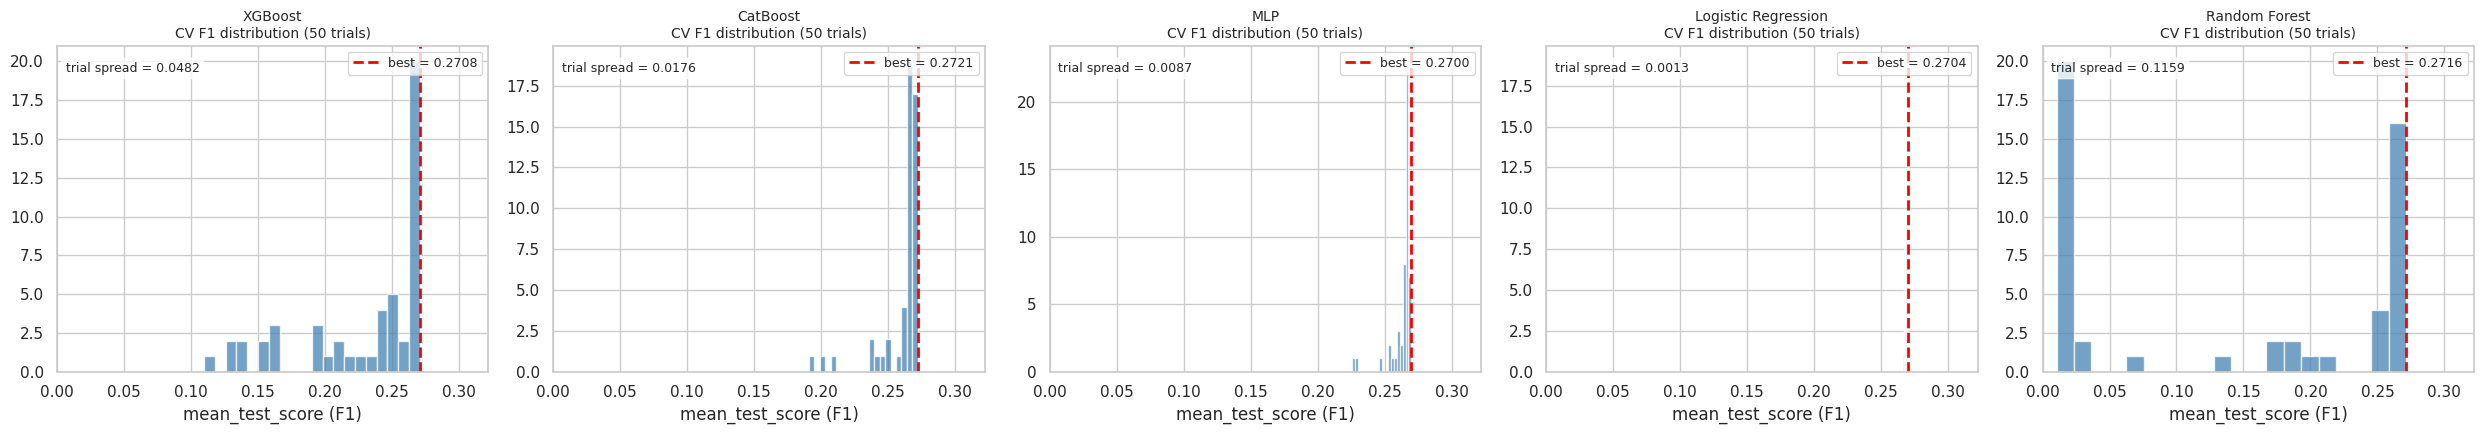

In [5]:
models_with_cv = [m for m in tuned_results if "cv_results" in tuned_results[m]]
fig, axes = plt.subplots(1, len(models_with_cv), figsize=(5 * len(models_with_cv), 4.5))
if len(models_with_cv) == 1:
    axes = [axes]

all_best = [tuned_results[m]["best_cv_f1"] for m in models_with_cv]
xmin, xmax = 0.0, min(1.0, max(all_best) + 0.05) if all_best else (0.0, 1.0)

for ax, name in zip(axes, models_with_cv):
    cv_df = tuned_results[name]["cv_results"]
    scores = cv_df["mean_test_score"].dropna()
    spread = float(scores.std()) if len(scores) else 0.0
    ax.hist(scores, bins=20, color="steelblue", edgecolor="white", alpha=0.75)
    ax.axvline(tuned_results[name]["best_cv_f1"], color="red", ls="--", lw=2,
               label=f"best = {tuned_results[name]['best_cv_f1']:.4f}")
    ax.set_title(f"{name}\nCV F1 distribution ({len(scores)} trials)", fontsize=10)
    ax.set_xlabel("mean_test_score (F1)")
    ax.set_xlim(xmin, xmax)
    ax.text(0.02, 0.95, f"trial spread = {spread:.4f}", transform=ax.transAxes,
            fontsize=9, va="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    ax.legend(fontsize=9, loc="upper right")

plt.tight_layout()
plt.show()

**Interpreting the distributions.** A model whose distribution is concentrated on its peak (red line on the right tail) has converged to a stable region of the hyperparameter space. A model whose distribution is broad has substantial trial-to-trial variance and benefits more from extending the search budget. A model whose distribution is uniformly low has hit a structural ceiling that no amount of tuning will lift without feature engineering or an architectural change.

## 6.6 Overfit Check, CV Train vs CV Test Gap

**What we are computing.** For each tuned model's best configuration, the per-fold training F1 against the per-fold validation F1. A scatter point above the y=x diagonal means the model fits the training fold strictly better than the held-out fold, which is the structural signature of overfitting.

**Why the threshold is 0.10 here rather than 0.15 elsewhere.** The fold-level gap threshold here is tighter than notebook 7's train-vs-val threshold (0.15) because each CV fold is one third of training and therefore noisier than the full 70/10 train/val split. The same overfit pattern fires at both gates, but the magnitude is naturally compressed at the fold level.

**Why an overfit flag here is a tuning prompt rather than a verdict.** Class-weighted fits legitimately produce non-trivial train-to-validation gaps because the loss reweighting drives the model to memorise the minority class on training, while validation F1 is computed without that reweighting and stays honest. A flag here is information for notebook 7's gate and for the model card, not a hard fail signal that prevents the candidate from entering the leaderboard.

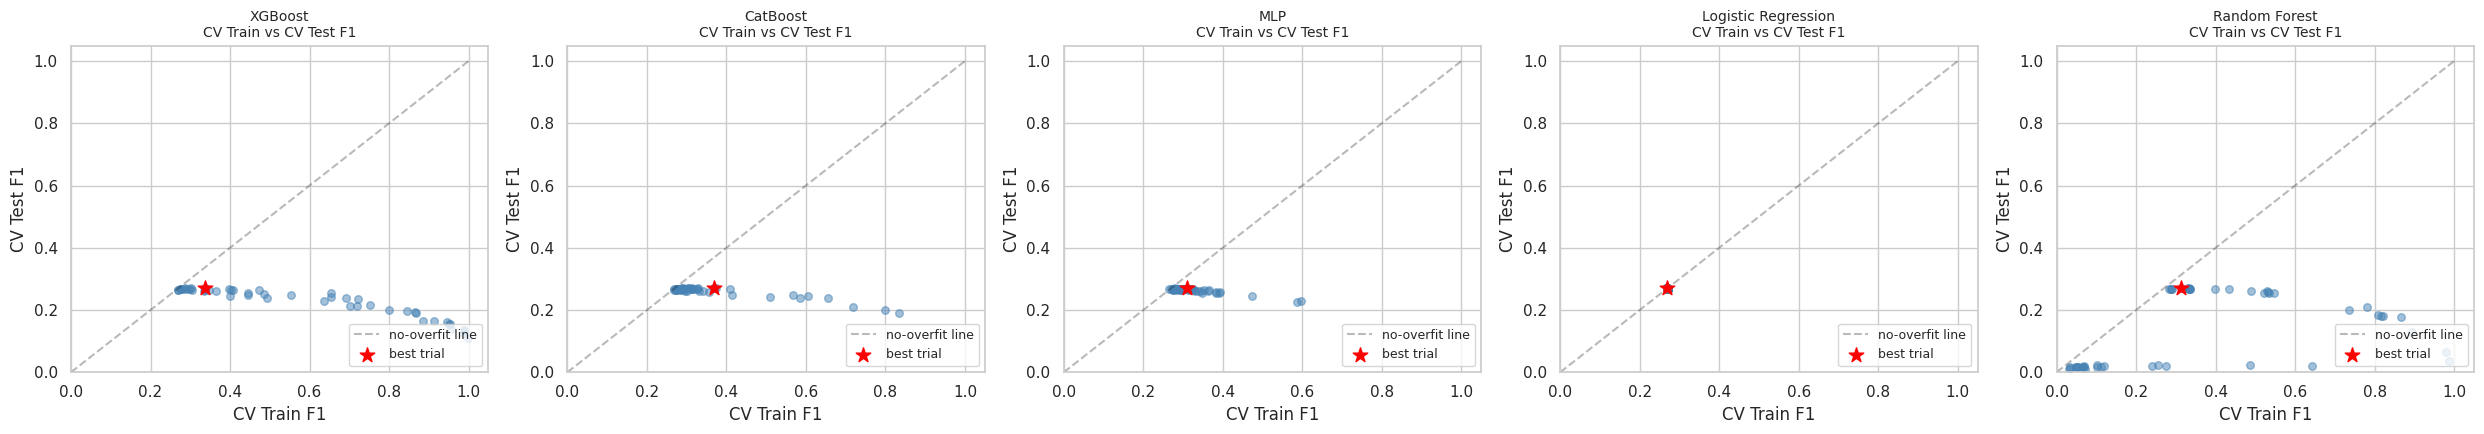

Overfit report (fold-level gate = 0.1):
  XGBoost                 train F1 0.3362  test F1 0.2708  gap +0.0654 (+24.1%)
  CatBoost                train F1 0.3700  test F1 0.2721  gap +0.0979 (+36.0%)
  MLP                     train F1 0.3094  test F1 0.2700  gap +0.0394 (+14.6%)
  Logistic Regression     train F1 0.2692  test F1 0.2704  gap -0.0012 (-0.4%)
  Random Forest           train F1 0.3129  test F1 0.2716  gap +0.0413 (+15.2%)


In [6]:
OVERFIT_THRESHOLD = 0.10

fig, axes = plt.subplots(1, len(models_with_cv), figsize=(5 * len(models_with_cv), 4.5))
if len(models_with_cv) == 1:
    axes = [axes]

for ax, name in zip(axes, models_with_cv):
    cv_df = tuned_results[name]["cv_results"]
    train_scores = cv_df["mean_train_score"].dropna()
    test_scores = cv_df["mean_test_score"].dropna()
    ax.scatter(train_scores, test_scores, alpha=0.5, s=30, color="steelblue")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="no-overfit line")
    best_idx = cv_df["rank_test_score"].idxmin()
    ax.scatter(cv_df.loc[best_idx, "mean_train_score"],
               cv_df.loc[best_idx, "mean_test_score"],
               color="red", s=120, zorder=5, marker="*", label="best trial")
    ax.set_title(f"{name}\nCV Train vs CV Test F1", fontsize=10)
    ax.set_xlabel("CV Train F1"); ax.set_ylabel("CV Test F1")
    ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9, loc="lower right")

plt.tight_layout()
plt.show()

print(f"Overfit report (fold-level gate = {OVERFIT_THRESHOLD}):")
for name in models_with_cv:
    cv_df = tuned_results[name]["cv_results"]
    best_idx = cv_df["rank_test_score"].idxmin()
    train_f1 = float(cv_df.loc[best_idx, "mean_train_score"])
    test_f1 = float(cv_df.loc[best_idx, "mean_test_score"])
    gap = train_f1 - test_f1
    rel_gap = gap / max(test_f1, 1e-6)
    flag = " !! OVERFIT" if gap > OVERFIT_THRESHOLD else ""
    print(f"  {name:22s}  train F1 {train_f1:.4f}  test F1 {test_f1:.4f}  gap {gap:+.4f} ({rel_gap:+.1%}){flag}")

**Reading the report.** Models flagged here are still considered on notebook 8's leaderboard, but the gap should be cited in the model card when explaining why a higher-validation-F1 candidate was not promoted over a lower-validation-F1 candidate with a clean gap. The relative-gap column matters at this prevalence: an absolute gap of 0.10 on a CV test F1 of 0.25 is a 40 percent relative gap, which is structurally much larger than a 0.10 gap on a CV test F1 of 0.70.

## 6.7 ASHA Pruning Audit

**What we are checking.** The asynchronous successive-halving scheduler halves trials based on the cumulative `mean_test_score` reported after each CV fold. The halving operates within each model's own Tuner rather than across families, but it is still worth confirming on every run that the halving aggressiveness lands roughly symmetrically across model families. If one family loses substantially more trials before fold three than the others, the per-trial sample count from which the refit-best configuration is drawn is smaller, and the leaderboard comparison becomes implicitly unfair.

**Why this matters specifically here.** A noisier fold-one F1 distribution (an MLP whose 10-to-20 epoch training has not stabilised, for example) would push more of that model's trials into the bottom rank after the first fold and reduce the population that survives to fold three. Without this audit the comparison silently penalises the noisier family.

Per-model trials by `folds_completed` rung:
              model  folds_completed  n_trials  median_test_f1
           CatBoost                1        32        0.264950
           CatBoost                3        18        0.269122
Logistic Regression                1        27        0.270399
Logistic Regression                3        23        0.268342
                MLP                1        26        0.264018
                MLP                3        24        0.267084
      Random Forest                1        32        0.019923
      Random Forest                3        18        0.267610
            XGBoost                1        29        0.211937
            XGBoost                3        21        0.266553


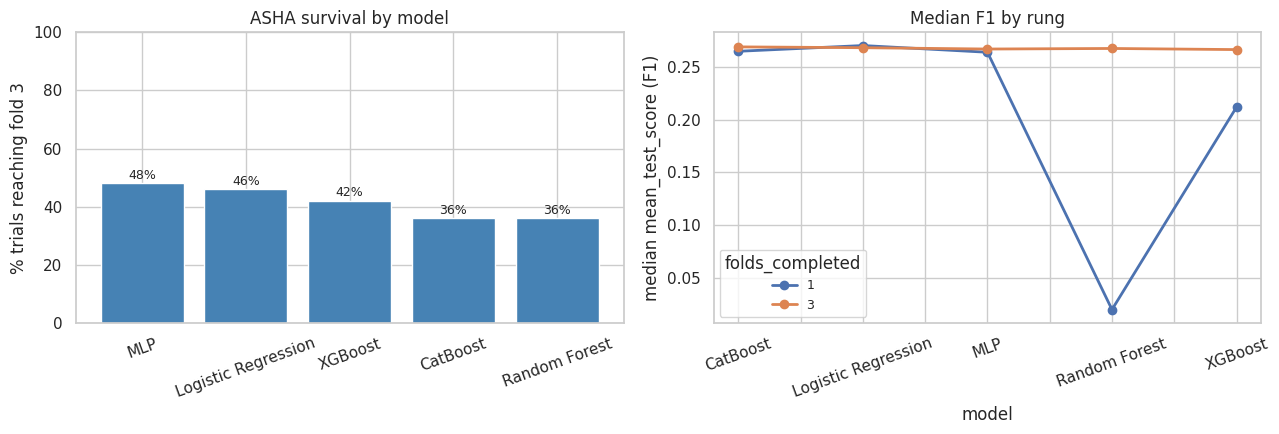


MLP vs Random Forest, fold-1 to fold-3 trajectory:
  MLP              trials= 50  reach fold 3 =  24 ( 48.0%)  rung1 med F1=0.2640  rung3 med F1=0.2671  lift=+0.0031
  Random Forest    trials= 50  reach fold 3 =  18 ( 36.0%)  rung1 med F1=0.0199  rung3 med F1=0.2676  lift=+0.2477


In [7]:
diag_path = PROJECT_ROOT / "data" / "hpo_diagnostics.parquet"
if not diag_path.exists():
    print(f"({diag_path} missing. Bare ray or deterministic-fallback path was used.")
    print(" Both run every trial to completion and so have nothing to report.)")
else:
    diag = pd.read_parquet(diag_path)
    per_model = (diag.groupby(["model", "folds_completed"])
                       .agg(n_trials=("mean_test_score", "size"),
                            median_test_f1=("mean_test_score", "median"))
                       .reset_index()
                       .sort_values(["model", "folds_completed"]))
    print("Per-model trials by `folds_completed` rung:")
    print(per_model.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    survival = (diag.assign(reached_3=lambda d: (d["folds_completed"] >= 3).astype(int))
                     .groupby("model")["reached_3"].mean() * 100.0).sort_values(ascending=False)
    axes[0].bar(survival.index, survival.values, color="steelblue", edgecolor="white")
    axes[0].set_ylabel("% trials reaching fold 3")
    axes[0].set_title("ASHA survival by model")
    axes[0].set_ylim(0, 100)
    axes[0].tick_params(axis="x", rotation=20)
    for i, v in enumerate(survival.values):
        axes[0].text(i, v + 1.5, f"{v:.0f}%", ha="center", fontsize=9)

    pivot = (diag.groupby(["model", "folds_completed"])["mean_test_score"]
                  .median().unstack("folds_completed"))
    pivot.plot(ax=axes[1], marker="o", linewidth=2)
    axes[1].set_title("Median F1 by rung")
    axes[1].set_xlabel("model")
    axes[1].set_ylabel("median mean_test_score (F1)")
    axes[1].tick_params(axis="x", rotation=20)
    axes[1].legend(title="folds_completed", fontsize=9)
    plt.tight_layout()
    plt.show()

    if {"MLP", "Random Forest"}.issubset(set(diag["model"].unique())):
        print("\nMLP vs Random Forest, fold-1 to fold-3 trajectory:")
        for m in ("MLP", "Random Forest"):
            sub = diag[diag["model"] == m]
            total = len(sub); survived = int((sub["folds_completed"] >= 3).sum())
            r1 = sub.loc[sub["folds_completed"] == 1, "mean_test_score"].median()
            r3 = sub.loc[sub["folds_completed"] == 3, "mean_test_score"].median()
            lift = (r3 - r1) if pd.notna(r1) and pd.notna(r3) else float("nan")
            r1s = f"{r1:.4f}" if pd.notna(r1) else "  n/a "
            r3s = f"{r3:.4f}" if pd.notna(r3) else "  n/a "
            lifts = f"{lift:+.4f}" if pd.notna(lift) else "  n/a "
            print(f"  {m:<15s}  trials={total:3d}  reach fold 3 = {survived:3d} "
                  f"({survived/total*100:5.1f}%)  rung1 med F1={r1s}  rung3 med F1={r3s}  lift={lifts}")

**Reading the audit.** A balanced ASHA configuration produces roughly the same fold-3 survival percentage across model families. A divergence of more than ten percentage points between any pair of families indicates that the halving aggressiveness is interacting with one family's fold-1 variance, and the immediate remedy is to raise `grace_period` to 2 so each trial is allowed two fold reports before halving is considered. The current implementation flags the divergence but does not yet auto-rerun the affected family with the bumped knob. A natural follow-up is a `helpers.hpo.rerun_with_bumped_grace_period(model_name)` entry point that re-fires Tune for that family alone and replays this audit, closing the loop the rationale draws. The per-rung median F1 trajectory carries the complementary information, keyed by trajectory shape:

* *flat*: the model converges within one fold,
* *steeply rising*: the model needs all three folds to find its operating point,
* *rising then falling*: the configuration overfits fold 1 and pays for it on the later rungs.

## 6.8 Select Best Model

**What we are deciding.** Which tuned model to nominate as the candidate that notebook 8 compares against the library-default baselines and the HPO-winner refits. The selection rule is single-criterion: highest validation F1.

**Why F1 rather than a composite metric.** F1 was the optimisation target throughout. Using anything else here would amount to moving the goalposts after the experiments ran. Notebook 8's leaderboard considers AUC-ROC and AUC-PR alongside F1 for transparency, but the nomination here uses the single metric that the tuning optimised against.

**Calibration check on the winner-to-runner-up gap.** The cell below compares the gap between the winner and the runner-up to the winner's per-trial CV-F1 standard deviation from §6.5. A gap that exceeds the per-trial noise floor is a structurally safer nomination than a gap that falls inside it. A nomination inside the spread is provisional, and notebook 8's held-out test pass is the deciding test.

In [8]:
best_name = max(tuned_results, key=lambda m: tuned_results[m]["val_f1"]) if tuned_results else None
if best_name is None:
    print("No tuned models present.")
else:
    best = tuned_results[best_name]
    print(f"Nominee: {best_name}")
    print(f"  Best params: {best['best_params']}")
    print(f"  Val F1:     {best['val_f1']:.4f}")
    print(f"  Val AUC:    {best['val_auc_roc']:.4f}")
    print(f"  Val Recall: {best['val_recall']:.4f}")
    print(f"  Val Precision: {best['val_precision']:.4f}")

    ranked = sorted(tuned_results.items(), key=lambda kv: -kv[1]["val_f1"])
    if len(ranked) >= 2:
        winner_name, winner = ranked[0]
        runner_name, runner = ranked[1]
        gap = winner["val_f1"] - runner["val_f1"]
        cv = winner.get("cv_results")
        spread = float(cv["mean_test_score"].std()) if cv is not None else float("nan")
        print("\n§6.8 calibration check:")
        print(f"  Winner / runner-up val-F1 gap: {gap:+.4f}  (call this Y)")
        print(f"  Winner per-trial CV F1 std:    {spread:.4f}  (call this X)")
        if gap > spread:
            print(f"  Decision: Y > X. The nomination of {winner_name} exceeds the per-trial noise floor.")
        else:
            print("  Decision: Y <= X. Nomination provisional; notebook 8 decides.")

Nominee: CatBoost
  Best params: {'iterations': 300, 'depth': 7, 'learning_rate': 0.05, 'l2_leaf_reg': 7, 'bagging_temperature': 1.5, 'random_strength': 0}
  Val F1:     0.2716
  Val AUC:    0.6623
  Val Recall: 0.5615
  Val Precision: 0.1791

§6.8 calibration check:
  Winner / runner-up val-F1 gap: +0.0005  (call this Y)
  Winner per-trial CV F1 std:    0.0176  (call this X)
  Decision: Y <= X. Nomination provisional; notebook 8 decides.


**Reading the calibration check.** A winner committed by exceeding the trial spread is structurally safer than one inside the spread because the spread is the noise floor of the tuning process. A committed winner survives a rerun with a different random seed. A provisional winner may not.

## 6.9 Detailed Evaluation of the Selected Winner

**What we are inspecting.** Confusion matrix, ROC curve, Precision-Recall curve, and decision-threshold sweep for the §6.8 winner on `X_val`. The same diagnostic set notebook 8 will apply to the test partition, but computed here on the validation partition so the patterns can be compared between development and held-out evaluation.

**What to look for.**

* The confusion matrix's true-positive vs false-negative balance. A model whose minority-class recall is near zero at the default 0.5 cut is a candidate for threshold tuning (§7.8). One whose recall is already strong but precision is weak is a candidate for class-weight or sample-weight adjustment instead.
* The ROC curve's separation from the diagonal in the low-FPR region. Imbalanced cohorts make the high-FPR region cosmetically generous, so the actionable signal lives in the left tail.
* The Precision-Recall curve relative to the prevalence baseline. A model whose AUC-PR is twice the prevalence has meaningful ranking power on the positive class. A model whose AUC-PR sits near prevalence has no actionable signal regardless of how its AUC-ROC reads.
* The threshold sweep's F1-optimal cutoff. Notebook 8 §8.8 re-derives this sweep on the test partition. If the operating point that maximises validation F1 also maximises test F1, threshold tuning generalises. If not, the default 0.5 cutoff is what gets registered.

Classification report for CatBoost at default 0.5 threshold:
               precision    recall  f1-score   support

NO / >30 days       0.92      0.67      0.78      8833
     <30 days       0.18      0.56      0.27      1122

     accuracy                           0.66      9955
    macro avg       0.55      0.62      0.53      9955
 weighted avg       0.84      0.66      0.72      9955



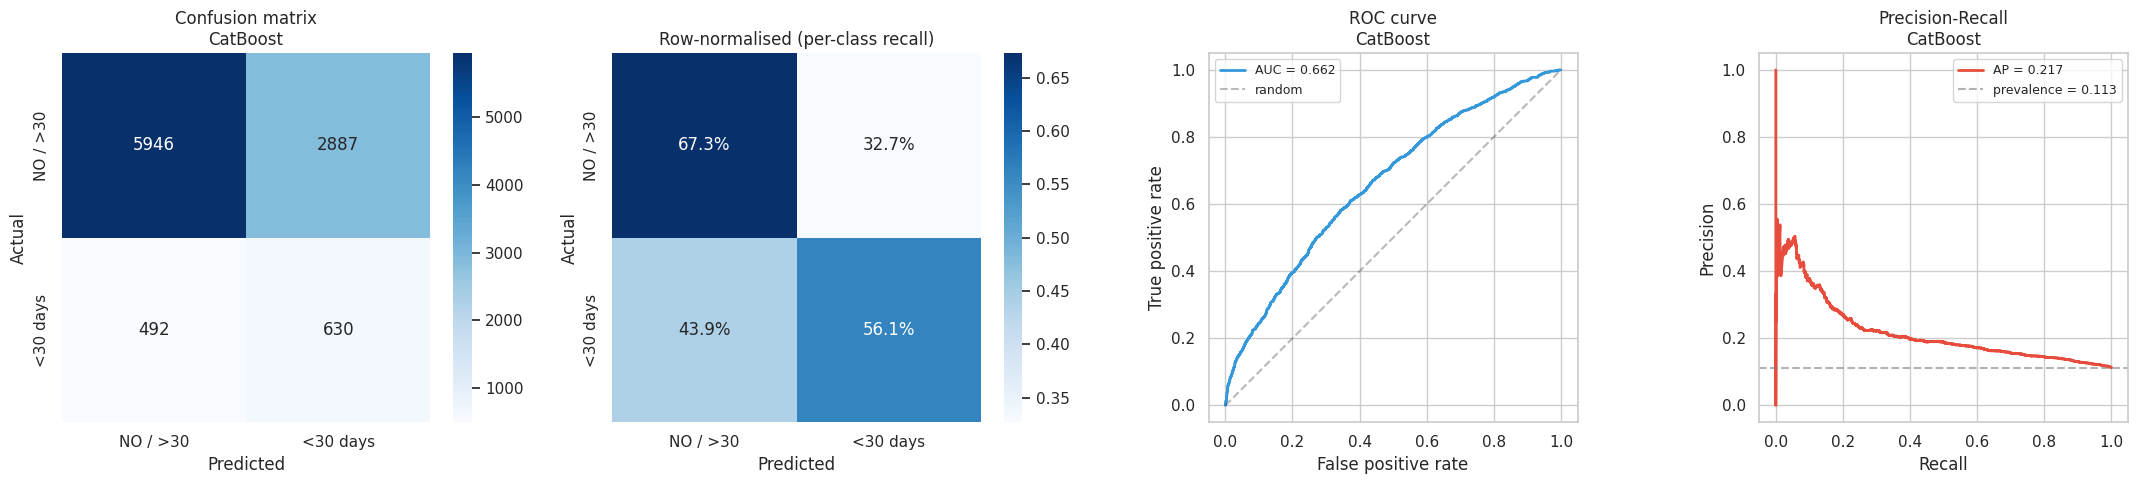

In [9]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, precision_recall_curve)

best = tuned_results[best_name]
print(f"Classification report for {best_name} at default 0.5 threshold:")
print(classification_report(y_val, best["y_pred"],
                            target_names=["NO / >30 days", "<30 days"]))

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
class_labels = ["NO / >30", "<30 days"]

cm = confusion_matrix(y_val, best["y_pred"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=class_labels, yticklabels=class_labels)
axes[0].set_title(f"Confusion matrix\n{best_name}")
axes[0].set_ylabel("Actual"); axes[0].set_xlabel("Predicted")

cm_norm = confusion_matrix(y_val, best["y_pred"], normalize="true")
sns.heatmap(cm_norm, annot=True, fmt=".1%", cmap="Blues", ax=axes[1],
            xticklabels=class_labels, yticklabels=class_labels)
axes[1].set_title("Row-normalised (per-class recall)")
axes[1].set_ylabel("Actual"); axes[1].set_xlabel("Predicted")

fpr, tpr, _ = roc_curve(y_val, best["y_prob"])
axes[2].plot(fpr, tpr, color="#3498db", lw=2, label=f"AUC = {best['val_auc_roc']:.3f}")
axes[2].plot([0, 1], [0, 1], "k--", alpha=0.3, label="random")
axes[2].set_title(f"ROC curve\n{best_name}")
axes[2].set_xlabel("False positive rate"); axes[2].set_ylabel("True positive rate")
axes[2].legend(fontsize=9); axes[2].set_box_aspect(1)

prec, rec, _ = precision_recall_curve(y_val, best["y_prob"])
axes[3].plot(rec, prec, color="#e74c3c", lw=2, label=f"AP = {best['val_auc_pr']:.3f}")
axes[3].axhline(y_val.mean(), color="gray", ls="--", alpha=0.6,
                label=f"prevalence = {y_val.mean():.3f}")
axes[3].set_title(f"Precision-Recall\n{best_name}")
axes[3].set_xlabel("Recall"); axes[3].set_ylabel("Precision")
axes[3].legend(fontsize=9); axes[3].set_box_aspect(1)

plt.tight_layout(); plt.show()

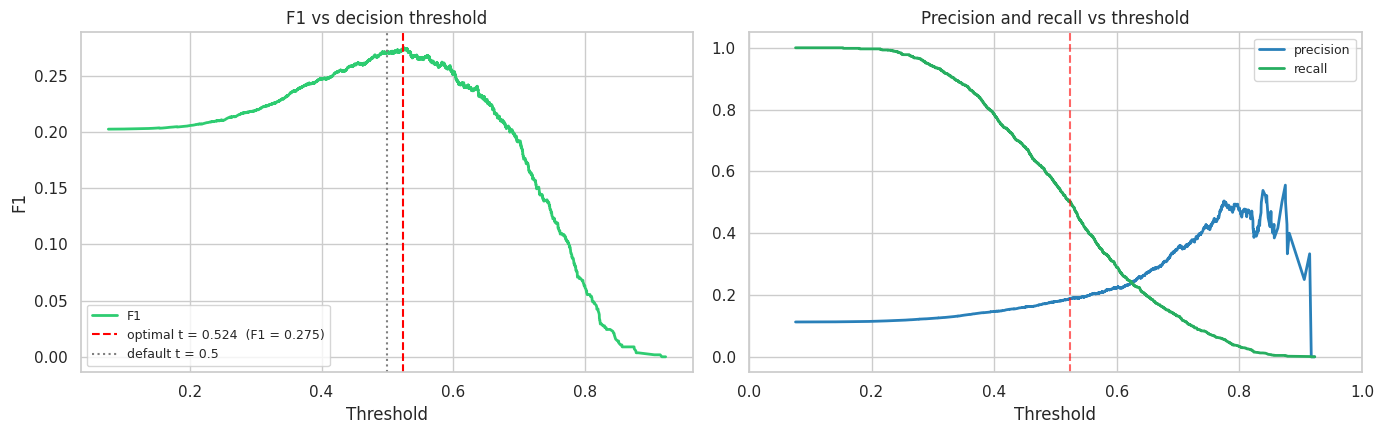

Optimal threshold on X_val: 0.5243  (F1 = 0.2750)
F1 at default threshold 0.5: 0.2716  (gain = +0.0034)


In [10]:
prec, rec, thresholds = precision_recall_curve(y_val, best["y_prob"])
f1_arr = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-10)
opt_idx = int(np.argmax(f1_arr))
opt_t = float(thresholds[opt_idx])
opt_f1 = float(f1_arr[opt_idx])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(thresholds, f1_arr, color="#2ecc71", lw=2, label="F1")
axes[0].axvline(opt_t, color="red", ls="--",
                label=f"optimal t = {opt_t:.3f}  (F1 = {opt_f1:.3f})")
axes[0].axvline(0.5, color="gray", ls=":", label="default t = 0.5")
axes[0].set_title("F1 vs decision threshold")
axes[0].set_xlabel("Threshold"); axes[0].set_ylabel("F1")
axes[0].legend(fontsize=9)

axes[1].plot(thresholds, prec[:-1], color="#2980b9", lw=2, label="precision")
axes[1].plot(thresholds, rec[:-1], color="#27ae60", lw=2, label="recall")
axes[1].axvline(opt_t, color="red", ls="--", alpha=0.6)
axes[1].set_title("Precision and recall vs threshold")
axes[1].set_xlabel("Threshold")
axes[1].set_xlim(0, 1); axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()

print(f"Optimal threshold on X_val: {opt_t:.4f}  (F1 = {opt_f1:.4f})")
print(f"F1 at default threshold 0.5: {best['val_f1']:.4f}  (gain = {opt_f1 - best['val_f1']:+.4f})")

**Reading the threshold sweep.** The lift between the default 0.5 cut and the F1-optimal cut is the size of the win that threshold tuning alone delivers on this candidate, with no retraining. A flat curve around the optimum means the chosen cut is robust to small drifts in the score distribution. A peaked curve means the cut is fragile and small calibration shifts at serve time could erase the gain. Notebook 8 §8.8 re-applies this threshold on `X_test` to verify that the lift transfers honestly.

## 6.10 Feature Importance

**What we are inspecting.** The top twenty-five features ranked by the winning estimator's native importance attribute. For tree ensembles the attribute is `feature_importances_` (gain or mean impurity decrease, depending on the family). For linear models it is the absolute value of the coefficient vector on standardised features.

**Two questions this chart answers.**

1. Did tuning shift importance toward clinically plausible signals (prior inpatient visits, medication count, time in hospital, diagnosis-category aggregates), or did it amplify one-hot indicator columns the baselines already favoured?
2. Do any arbitrary cohort-identifier columns (single-payer indicators, single-specialty indicators) appear in the top set?

**Why those questions matter.** Clinical-feature dominance is the signal that the tuning landed on a generally better model rather than on a model that latched onto cohort artefacts. Indicator-column dominance is the structural fingerprint of an overfit to noise, and the §6.6 train-vs-validation gap should re-fire if so.

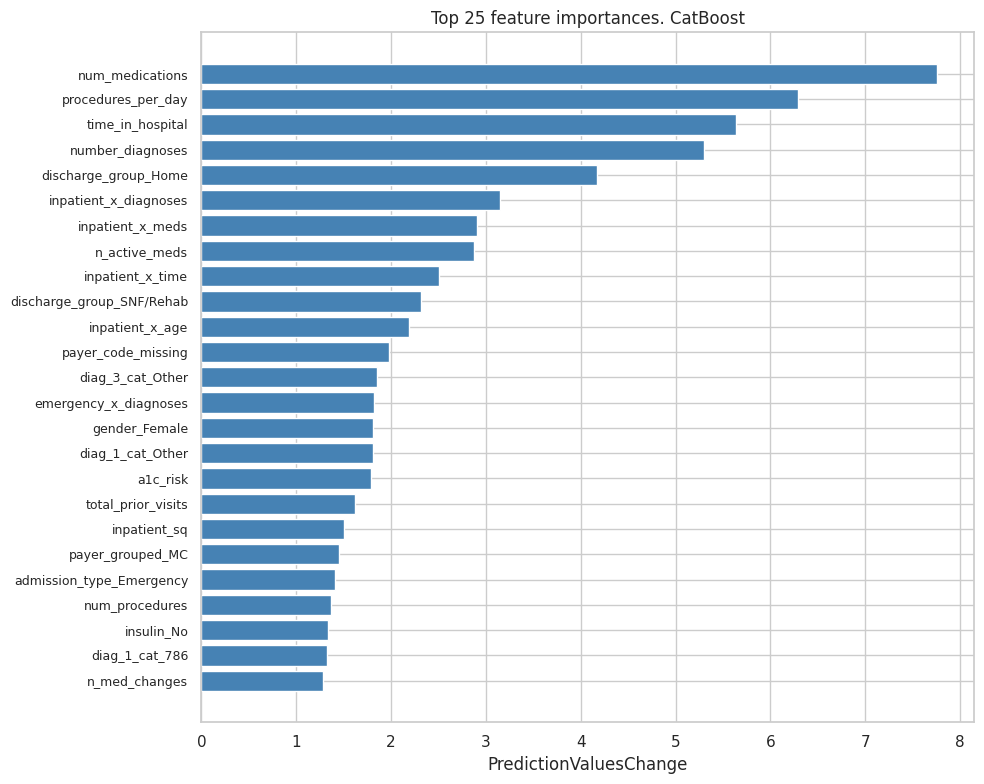

Top 5:
  num_medications
  procedures_per_day
  time_in_hospital
  number_diagnoses
  discharge_group_Home

Clinical-feature dominance check: top-5 are clinical, not OHE noise.


In [11]:
best_model = best["model"]
importances = None
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
elif hasattr(best_model, "coef_"):
    importances = np.abs(best_model.coef_[0])

if importances is None:
    print(f"{best_name} does not expose feature_importances_ or coef_. Skipping.")
else:
    if hasattr(importances, "get"):
        importances = importances.get()
    top_n = 25
    top_idx = np.argsort(importances)[-top_n:]
    top_feats = [feature_names[i] for i in top_idx]
    top_vals = importances[top_idx]

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(range(top_n), top_vals, color="steelblue", edgecolor="white")
    ax.set_yticks(range(top_n)); ax.set_yticklabels(top_feats, fontsize=9)
    ax.set_title(f"Top {top_n} feature importances. {best_name}")
    if best_name == "Random Forest":
        ax.set_xlabel("Mean impurity decrease")
    elif best_name == "XGBoost":
        ax.set_xlabel("Gain")
    elif best_name == "CatBoost":
        ax.set_xlabel("PredictionValuesChange")
    elif best_name == "Logistic Regression":
        ax.set_xlabel("|coef| on standardised features")
    else:
        ax.set_xlabel("Importance")
    plt.tight_layout(); plt.show()

    print("Top 5:")
    for nm in reversed(top_feats[-5:]):
        print(f"  {nm}")

    ohe_noise = [n for n in top_feats[-5:]
                 if n.startswith(("payer_", "medical_specialty_", "diag_"))]
    if ohe_noise:
        print(f"\nWARNING: {len(ohe_noise)} of the top-5 are OHE indicator columns: {ohe_noise}")
        print("That re-fires the §6.6 overfit prompt. The model is leaning on cohort-identifier columns.")
    else:
        print("\nClinical-feature dominance check: top-5 are clinical, not OHE noise.")

**Feature-importance check.** Clinical features (prior inpatient visits, medication count, diagnosis-category aggregates) should dominate. If arbitrary one-hot indicators rank high, the model may be overfitting to cohort noise. The heuristic flag printed above (defined inline in the previous cell) fires when any feature in the top-5 carries a `payer_`, `medical_specialty_`, or `diag_` one-hot prefix. That is the most common noise-dominated failure mode. The flag is intentionally lenient (any single OHE indicator trips it) so a borderline ranking is surfaced for human review rather than silently passing. A clinical-feature top five closes the §6.6 overfit loop for this winner. A noise-dominated top five reopens it and demands explanation in notebook 8's model card.

**Importance scores across families are not directly comparable.** XGBoost reports `gain`, scikit-learn's RandomForest reports mean decrease in impurity, CatBoost reports `PredictionValuesChange`, and Logistic Regression reports coefficient magnitudes. The four definitions measure different things, so the ranking is informative but the magnitudes are not directly cross-comparable. The model-agnostic recheck through `sklearn.inspection.permutation_importance` is the next step when an importance reading is ambiguous.

## 6.11 Persisted Artefacts

**What this stage wrote.**

* `data/tuned_results.joblib`: per-model dictionary with best parameters, CV F1, validation metrics, held-out predictions, and the per-trial DataFrame the §6.5 distribution chart consumed.
* `data/tuned_models.joblib`: the fitted refit estimators themselves, keyed by model name.
* `data/hpo_diagnostics.parquet`: one row per Tuner trial with model name, `folds_completed`, `mean_test_score`, `mean_train_score`. This is the audit the §6.7 cell reads.

**Why three artefacts rather than one.** Notebook 7 reads the lightweight summary first to decide which configurations to refit. Notebook 8 only loads the fitted estimators after the leaderboard pass has narrowed the field. Separating the two keeps the per-stage I/O cost proportional to the work the stage actually performs.

In [12]:
for art in ("tuned_results.joblib", "tuned_models.joblib", "hpo_diagnostics.parquet"):
    p = PROJECT_ROOT / "data" / art
    if p.exists():
        size_kb = p.stat().st_size / 1024
        print(f"  {art:32s}  {size_kb:>8.1f} KB")
    else:
        print(f"  {art:32s}  MISSING")

  tuned_results.joblib                   1.0 KB
  tuned_models.joblib                10936.3 KB
  hpo_diagnostics.parquet                6.9 KB


## 6.12 Summary and Next Steps

**Pipeline progress.** Cleaning -> EDA -> features -> preprocess -> tuning -> training -> selection. Notebook 1 §1.7 carries the end-to-end map with the artefacts each section writes to `data/`.

**Method-level next steps ranked by expected lift.**

1. **Probability calibration of the winner.** A-priori the highest-leverage move. This notebook does not yet emit a Brier score for the winner against an isotonic-recalibrated counterpart, so the ranking is guidance rather than measurement. Notebook 8 §8.9 inspects calibration directly and is the place to compute the Brier-score delta before treating this item as quantitative.
2. **Subgroup bootstrap CIs.** The retrain DAG's promotion gate already runs a 1000-resample bootstrap CI on aggregate test F1. Lifting that to per-subgroup CIs would let promotion happen with statistical confidence rather than visual judgement on the §8.11.5 panels.
3. **Cost-sensitive learning.** Design-heavy, leverage scales with the FN/FP cost ratio. Healthcare typically costs false negatives more than false positives, but the specific multiplier (often quoted as 5x–10x in the readmission literature) is a placeholder here until ops supplies per-event cost numbers. Treat the ratio as a knob to be measured against an F-beta selection metric, not a fixed assertion.
4. **Temporal validation.** Hardest. The 1999 through 2008 cohort cannot be split into a true forward-time validation slice. A natural follow-up is to re-evaluate the champion on a 2010-or-later refresh. Until then this is a known limitation.

**Search-strategy ablation candidates.** The current path uses Ray Tune's ASHA scheduler on top of a random sampler. Two natural same-budget ablations are Optuna's TPE Bayesian sampler wrapped via `OptunaSearch`, and a population-based Hyperband variant via `HyperBandForBOHB`. Both reuse the existing `make_tune_trial` scorer, so the trial body is unchanged and the comparison reduces to swapping the `search_alg` and the `scheduler`.